# Week 2: Naive Bayes for Sentiment Analysis


## NLP Specialization - Course 1

This notebook provides hands-on implementation of the Naive Bayes classifier for tweet sentiment analysis, complementing the theoretical concepts from your Week 2 notes.

---

## 1. Setup and Imports

Import necessary libraries for implementing Naive Bayes classifier. We'll use NumPy for numerical operations, Pandas for data handling, and Matplotlib for visualizations. Setting a random seed ensures reproducible results.


In [11]:
%pip install numpy pandas matplotlib seaborn scikit-learn

   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/8.9 MB 5.6 MB/s eta 0:00:02
   -------- ------------------------------- 1.8/8.9 MB 4.8 MB/s eta 0:00:02
   ---------- ----------------------------- 2.4/8.9 MB 4.5 MB/s eta 0:00:02
   ---------------- ----------------------- 3.7/8.9 MB 4.1 MB/s eta 0:00:02
   -------------------- ------------------- 4.5/8.9 MB 4.1 MB/s eta 0:00:02
   ---------------------- ----------------- 5.0/8.9 MB 4.0 MB/s eta 0:00:01
   ------------------------- -------------- 5.8/8.9 MB 3.8 MB/s eta 0:00:01
   ----------------------------- ---------- 6.6/8.9 MB 3.8 MB/s eta 0:00:01
   --------------------------------- ------ 7.3/8.9 MB 3.8 MB/s eta 0:00:01
   ------------------------------------ --- 8.1/8.9 MB 3.8 MB/s eta 0:00:01
   -------------------------------------- - 8.7/8.9 MB 3.8 MB/s eta 0:00:01
   ---------------------------------------- 8.9/8.9 MB 3.7 MB/s  0:00:02
   -------------------

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import re
import string
from sklearn.metrics import confusion_matrix

# Set random seed for reproducibility
np.random.seed(42)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
plt.style.use('seaborn-v0_8-darkgrid')

## 2. Create Sample Tweet Dataset

Creating a small dataset to demonstrate Naive Bayes concepts from the notes.

Creating a balanced dataset of 12 tweets (6 positive, 6 negative) similar to examples in your notes. This small dataset helps us understand each step of the Naive Bayes algorithm. We'll print the shape, class distribution, and sample data to understand our dataset structure.


In [3]:
# Sample tweets dataset
tweets = [
    "I love this amazing movie",
    "Great acting performance",
    "Happy because learning NLP",
    "I am happy today",
    "Amazing film",
    "I passed the exam",
    "I hate this terrible movie",
    "Bad acting performance",
    "I am sad today",
    "Terrible film",
    "I am not happy",
    "This is not good"
]

# labels: 1 = positive and 0 = negative
labels = [1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]

# create DataFrame
df = pd.DataFrame({'tweet': tweets, 'label': labels})
print("Dataset Shape:", df.shape)
print("\nClass Distribution:")
print(df['label'].value_counts())
print("\nSample Data:")
print(df.head(8))

Dataset Shape: (12, 2)

Class Distribution:
label
1    6
0    6
Name: count, dtype: int64

Sample Data:
                        tweet  label
0   I love this amazing movie      1
1    Great acting performance      1
2  Happy because learning NLP      1
3            I am happy today      1
4                Amazing film      1
5           I passed the exam      1
6  I hate this terrible movie      0
7      Bad acting performance      0


## 3. Text Preprocessing

Implementing the 5-step preprocessing pipeline from Section 2 of your notes:

1.  Lowercase conversion
2.  Remove punctuation and URLs
3.  Remove stop words (like "I", "am", "the")
4.  Simple stemming (removing suffixes like -ing, -ed, -s)
5.  Tokenization (splitting into words)

This transforms raw tweets into clean word lists that our model can process. We'll see b


In [ ]:
def preprocess_tweet(tweet):
    """
    Preprocess tweet using 5-step pipeline:
    1. Lowercase
    2. Remove punctuation & URLs
    3. Remove stop words
    4. Stemming (simplified)
    5. Tokenization
    """
    # Step 1: Lowercase
    tweet = tweet.lower()

    # Step 2: Remove punctuation
    tweet = tweet.translate(str.maketrans('', '', string.punctuation))

    # Step 3: Remove stop words (simplified list)
    stop_words = {'i', 'am', 'is', 'the', 'this', 'a', 'an', 'it', 'its'}

    # Step 4 & 5: Simple stemming and tokenization
    words = tweet.split()

    # Simple stemming rules
    def simple_stem(word):
        if word.endswith('ing'):
            return word[:-3]
        if word.endswith('ed'):
            return word[:-2]
        if word.endswith('s') and len(word) > 3:
            return word[:-1]
        return word

    processed_words = []               # Create an empty list to store processed words

    for w in words:                    # Loop through each word in the list 'words'
        if w not in stop_words:        # Check if the word is NOT a stop word
            stemmed_word = simple_stem(w)   # Apply stemming to the word
            processed_words.append(stemmed_word)  # Add the stemmed word to the list

    return processed_words

# Apply preprocessing
df['processed'] = df['tweet'].apply(preprocess_tweet)

print("Preprocessing Examples:")
print("\nOriginal → Processed")
print("-" * 50)
for i in range(5):
    print(f"{df.iloc[i]['tweet']}")
    print(f"  → {df.iloc[i]['processed']}")
    print()

Preprocessing Examples:

Original → Processed
--------------------------------------------------
I love this amazing movie
  → ['love', 'amaz', 'movie']

Great acting performance
  → ['great', 'act', 'performance']

Happy because learning NLP
  → ['happy', 'because', 'learn', 'nlp']

I am happy today
  → ['happy', 'today']

Amazing film
  → ['amaz', 'film']



## 4. Build Frequency Table (Step 3 from Notes)

Computing `freq(word, class)` - how many times each word appears in positive vs negative tweets. This is Step 3 from Section 7 (Training) in your notes. We calculate:

- **N_pos**: Total words in positive tweets
- **N_neg**: Total words in negative tweets
- **V**: Vocabulary size (unique words)

The frequency table is the foundation for calculating probabilities in the next step.


In [5]:
def build_frequency_table(df):
    """
    Build frequency table: freq(word, class)
    Returns: frequency dictionary and vocabulary
    """
    freq_dict = defaultdict(lambda: {'pos': 0, 'neg': 0})

    for idx, row in df.iterrows():
        label = 'pos' if row['label'] == 1 else 'neg'
        for word in row['processed']:
            freq_dict[word][label] += 1

    return dict(freq_dict)

# Build frequency table
freq_table = build_frequency_table(df)

# Calculate totals and vocabulary
N_pos = sum(freq_table[word]['pos'] for word in freq_table)
N_neg = sum(freq_table[word]['neg'] for word in freq_table)
V = len(freq_table)

print(f"Total words in positive tweets: N_pos = {N_pos}")
print(f"Total words in negative tweets: N_neg = {N_neg}")
print(f"Vocabulary size: V = {V}")
print(f"\nFrequency Table (first 10 words):")
print("-" * 60)

# Create DataFrame for better visualization
freq_df = pd.DataFrame([
    {
        'Word': word,
        'Positive Count': counts['pos'],
        'Negative Count': counts['neg'],
        'Total': counts['pos'] + counts['neg']
    }
    for word, counts in freq_table.items()
]).sort_values('Total', ascending=False)

print(freq_df.head(10).to_string(index=False))

Total words in positive tweets: N_pos = 16
Total words in negative tweets: N_neg = 14
Vocabulary size: V = 20

Frequency Table (first 10 words):
------------------------------------------------------------
       Word  Positive Count  Negative Count  Total
      happy               2               1      3
       amaz               2               0      2
        act               1               1      2
      movie               1               1      2
      today               1               1      2
   terrible               0               2      2
performance               1               1      2
       film               1               1      2
        not               0               2      2
       love               1               0      1


## 5. Calculate Conditional Probabilities with Laplacian Smoothing (Step 4)

Implementing the smoothed probability formula from Section 4 of your notes:

**P(w|class) = (freq(w, class) + 1) / (N_class + V)**

Laplacian smoothing adds 1 to all counts to avoid zero probabilities. We calculate:

- P(w|positive) for each word
- P(w|negative) for each word
- Ratio of these probabilities

Words with ratio > 1 favor positive sentiment; ratio < 1 favor negative sentiment.

In [6]:
def calculate_probabilities(freq_table, N_pos, N_neg, V):
    """
    Calculate P(w|pos) and P(w|neg) with Laplacian smoothing
    Formula: P(w|class) = (freq(w, class) + 1) / (N_class + V)
    """
    prob_dict = {}

    for word in freq_table:
        # Laplacian smoothing
        p_w_pos = (freq_table[word]['pos'] + 1) / (N_pos + V)
        p_w_neg = (freq_table[word]['neg'] + 1) / (N_neg + V)

        prob_dict[word] = {
            'P(w|pos)': p_w_pos,
            'P(w|neg)': p_w_neg,
            'ratio': p_w_pos / p_w_neg
        }

    return prob_dict

# Calculate probabilities
prob_dict = calculate_probabilities(freq_table, N_pos, N_neg, V)

# Visualize probabilities
prob_df = pd.DataFrame([
    {
        'Word': word,
        'P(w|pos)': f"{probs['P(w|pos)']:.4f}",
        'P(w|neg)': f"{probs['P(w|neg)']:.4f}",
        'Ratio': f"{probs['ratio']:.4f}"
    }
    for word, probs in prob_dict.items()
]).sort_values('Ratio', ascending=False)

print("\nConditional Probabilities (Top 10 Positive Words):")
print(prob_df.head(10).to_string(index=False))
print("\n" + "="*60)
print("\nConditional Probabilities (Top 10 Negative Words):")
print(prob_df.tail(10).to_string(index=False))



Conditional Probabilities (Top 10 Positive Words):
   Word P(w|pos) P(w|neg)  Ratio
   amaz   0.0833   0.0294 2.8333
   love   0.0556   0.0294 1.8889
   exam   0.0556   0.0294 1.8889
  great   0.0556   0.0294 1.8889
   pass   0.0556   0.0294 1.8889
because   0.0556   0.0294 1.8889
  learn   0.0556   0.0294 1.8889
    nlp   0.0556   0.0294 1.8889
  happy   0.0833   0.0588 1.4167
   film   0.0556   0.0588 0.9444


Conditional Probabilities (Top 10 Negative Words):
       Word P(w|pos) P(w|neg)  Ratio
      today   0.0556   0.0588 0.9444
performance   0.0556   0.0588 0.9444
        act   0.0556   0.0588 0.9444
      movie   0.0556   0.0588 0.9444
       hate   0.0278   0.0588 0.4722
        bad   0.0278   0.0588 0.4722
        sad   0.0278   0.0588 0.4722
       good   0.0278   0.0588 0.4722
   terrible   0.0278   0.0882 0.3148
        not   0.0278   0.0882 0.3148


## 6. Calculate Lambda Scores (Step 5 from Notes)

Computing lambda (λ) scores from Section 5-6 of your notes:

**λ(w) = log(P(w|pos) / P(w|neg))**

Converting probability ratios to log space has two major benefits:

1.  Prevents numerical underflow (multiplying many small numbers)
2.  Converts multiplication to addition (faster computation)

**Interpretation:**

- λ > 0: Positive word
- λ < 0: Negative word
- λ ≈ 0: Neutral word

We'll visualize the distribution and see which words are "power words" that strongly indicate sentiment.



Lambda Dictionary (λ > 0 = Positive words):
   Word Lambda (λ)
   amaz     1.0415
   love     0.6360
  great     0.6360
because     0.6360
  learn     0.6360
    nlp     0.6360
   pass     0.6360
   exam     0.6360
  happy     0.3483
    not    -1.1558

Lambda Dictionary (λ < 0 = Negative words):
       Word Lambda (λ)
   terrible    -1.1558
       hate    -0.7503
        sad    -0.7503
        bad    -0.7503
       good    -0.7503
       film    -0.0572
performance    -0.0572
        act    -0.0572
      movie    -0.0572
      today    -0.0572


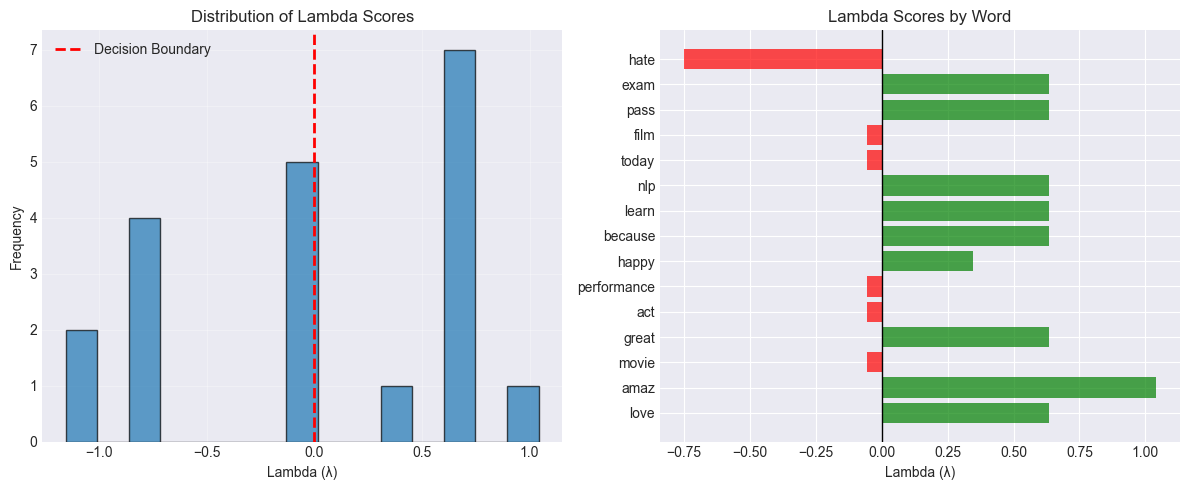

In [7]:
def calculate_lambda_scores(prob_dict):
    """
    Calculate lambda scores: λ(w) = log(P(w|pos) / P(w|neg))
    """
    lambda_dict = {}

    for word, probs in prob_dict.items():
        ratio = probs['P(w|pos)'] / probs['P(w|neg)']
        lambda_score = np.log(ratio)
        lambda_dict[word] = lambda_score

    return lambda_dict

# Calculate lambda scores
lambda_dict = calculate_lambda_scores(prob_dict)

# Visualize lambda scores
lambda_df = pd.DataFrame([
    {'Word': word, 'Lambda (λ)': f"{score:.4f}"}
    for word, score in lambda_dict.items()
]).sort_values('Lambda (λ)', ascending=False)

print("\nLambda Dictionary (λ > 0 = Positive words):")
print(lambda_df.head(10).to_string(index=False))
print("\nLambda Dictionary (λ < 0 = Negative words):")
print(lambda_df.tail(10).to_string(index=False))

# Visualize lambda distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
lambda_values = list(lambda_dict.values())
plt.hist(lambda_values, bins=15, edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Decision Boundary')
plt.xlabel('Lambda (λ)')
plt.ylabel('Frequency')
plt.title('Distribution of Lambda Scores')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
words = list(lambda_dict.keys())[:15]  # Top 15 words
scores = [lambda_dict[w] for w in words]
colors = ['green' if s > 0 else 'red' for s in scores]
plt.barh(words, scores, color=colors, alpha=0.7)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.xlabel('Lambda (λ)')
plt.title('Lambda Scores by Word')
plt.tight_layout()
plt.show()

## 7. Calculate Log Prior (Step 6 from Notes)

Computing the log prior from Section 7 (Step 6) of your notes:

**log_prior = log(D_pos / D_neg)**

Where D_pos and D_neg are the number of positive and negative documents. For balanced datasets, this equals 0 and doesn't affect classification. For imbalanced datasets, it adjusts predictions toward the more common class.


In [8]:
# Calculate log prior
D_pos = (df['label'] == 1).sum()
D_neg = (df['label'] == 0).sum()

log_prior = np.log(D_pos / D_neg)

print(f"Number of positive tweets: D_pos = {D_pos}")
print(f"Number of negative tweets: D_neg = {D_neg}")
print(f"Log Prior: log(D_pos/D_neg) = {log_prior:.4f}")

if abs(log_prior) < 0.1:
    print("\n✓ Dataset is balanced (log_prior ≈ 0)")
else:
    print(f"\n⚠ Dataset is imbalanced (log_prior = {log_prior:.4f})")

Number of positive tweets: D_pos = 6
Number of negative tweets: D_neg = 6
Log Prior: log(D_pos/D_neg) = 0.0000

✓ Dataset is balanced (log_prior ≈ 0)


## 8. Inference: Classify New Tweets (Section 6 & 8 from Notes)

Implementing the complete classification process from Sections 6 and 8 of your notes:

1.  Preprocess the new tweet
2.  Look up λ value for each word
3.  Sum all λ values (log likelihood)
4.  Add log_prior to get final score
5.  If score > 0: Positive, else: Negative

We'll test on several example tweets and show which words contributed to each prediction, including their individual λ contributions.


In [9]:
def predict_sentiment(tweet, lambda_dict, log_prior):
    """
    Predict sentiment using Naive Bayes
    Returns: prediction (1=pos, 0=neg), score, and word contributions
    """
    # Preprocess tweet
    words = preprocess_tweet(tweet)

    # Calculate log likelihood
    log_likelihood = 0
    word_contributions = []

    for word in words:
        if word in lambda_dict:
            lambda_score = lambda_dict[word]
            log_likelihood += lambda_score
            word_contributions.append((word, lambda_score))
        else:
            # Unknown word: contribute 0
            word_contributions.append((word, 0.0))

    # Calculate final score
    score = log_likelihood + log_prior

    # Make prediction
    prediction = 1 if score > 0 else 0

    return prediction, score, word_contributions

# Test on new tweets
test_tweets = [
    "I passed the NLP interview",
    "I am happy because I am learning",
    "This is terrible and bad",
    "Amazing performance",
    "I am not happy today"
]

print("\nClassification Results:")
print("="*80)

for tweet in test_tweets:
    pred, score, contributions = predict_sentiment(tweet, lambda_dict, log_prior)
    sentiment = "POSITIVE" if pred == 1 else "NEGATIVE"

    print(f"\nTweet: \"{tweet}\"")
    print(f"Prediction: {sentiment} (score = {score:.4f})")
    print(f"Word Contributions:")
    for word, contrib in contributions:
        print(f"  - {word}: {contrib:+.4f}")


Classification Results:

Tweet: "I passed the NLP interview"
Prediction: POSITIVE (score = 1.2720)
Word Contributions:
  - pass: +0.6360
  - nlp: +0.6360
  - interview: +0.0000

Tweet: "I am happy because I am learning"
Prediction: POSITIVE (score = 1.6203)
Word Contributions:
  - happy: +0.3483
  - because: +0.6360
  - learn: +0.6360

Tweet: "This is terrible and bad"
Prediction: NEGATIVE (score = -1.9061)
Word Contributions:
  - terrible: -1.1558
  - and: +0.0000
  - bad: -0.7503

Tweet: "Amazing performance"
Prediction: POSITIVE (score = 0.9843)
Word Contributions:
  - amaz: +1.0415
  - performance: -0.0572

Tweet: "I am not happy today"
Prediction: NEGATIVE (score = -0.8646)
Word Contributions:
  - not: -1.1558
  - happy: +0.3483
  - today: -0.0572


## 9. Evaluate Model Performance

Testing the trained model on our dataset to calculate accuracy (Section 8 of notes). We'll:

- Predict sentiment for each tweet
- Compare predictions to true labels
- Calculate accuracy percentage
- Show confusion matrix
- Display any misclassified tweets with their scores

This helps us understand where the model performs well and where it struggles.


In [13]:
def evaluate_model(df, lambda_dict, log_prior):
    """
    Evaluate model on dataset
    """
    predictions = []
    scores = []

    for idx, row in df.iterrows():
        pred, score, _ = predict_sentiment(row['tweet'], lambda_dict, log_prior)
        predictions.append(pred)
        scores.append(score)

    # Calculate accuracy
    df['predicted'] = predictions
    df['score'] = scores
    accuracy = (df['label'] == df['predicted']).mean()

    return accuracy, df

# Evaluate
accuracy, df_results = evaluate_model(df, lambda_dict, log_prior)

print(f"\nModel Accuracy: {accuracy*100:.2f}%")
print(f"\nConfusion Matrix:")

# Create confusion matrix
cm = confusion_matrix(df_results['label'], df_results['predicted'])
print(f"\n                Predicted")
print(f"              Neg    Pos")
print(f"Actual Neg    {cm[0,0]:3d}    {cm[0,1]:3d}")
print(f"       Pos    {cm[1,0]:3d}    {cm[1,1]:3d}")

# Show misclassifications
misclassified = df_results[df_results['label'] != df_results['predicted']]
if len(misclassified) > 0:
    print(f"\nMisclassified Tweets:")
    for idx, row in misclassified.iterrows():
        true_label = "Positive" if row['label'] == 1 else "Negative"
        pred_label = "Positive" if row['predicted'] == 1 else "Negative"
        print(f"  Tweet: \"{row['tweet']}\"")
        print(f"  True: {true_label}, Predicted: {pred_label} (score: {row['score']:.4f})")
        print()


Model Accuracy: 100.00%

Confusion Matrix:

                Predicted
              Neg    Pos
Actual Neg      6      0
       Pos      0      6


## 10. Visualize Decision Boundary

Creating four visualizations to understand how Naive Bayes makes decisions:

1.  **Vocabulary Distribution**: How many words appear in positive/negative tweets
2.  **Probability Comparison**: P(w|pos) vs P(w|neg) for sample words
3.  **Score Distribution**: How positive/negative tweets are separated by classification scores
4.  **Feature Importance**: Top "power words" with highest/lowest λ scores

These plots reveal the model's internal logic and show which words drive predictions.


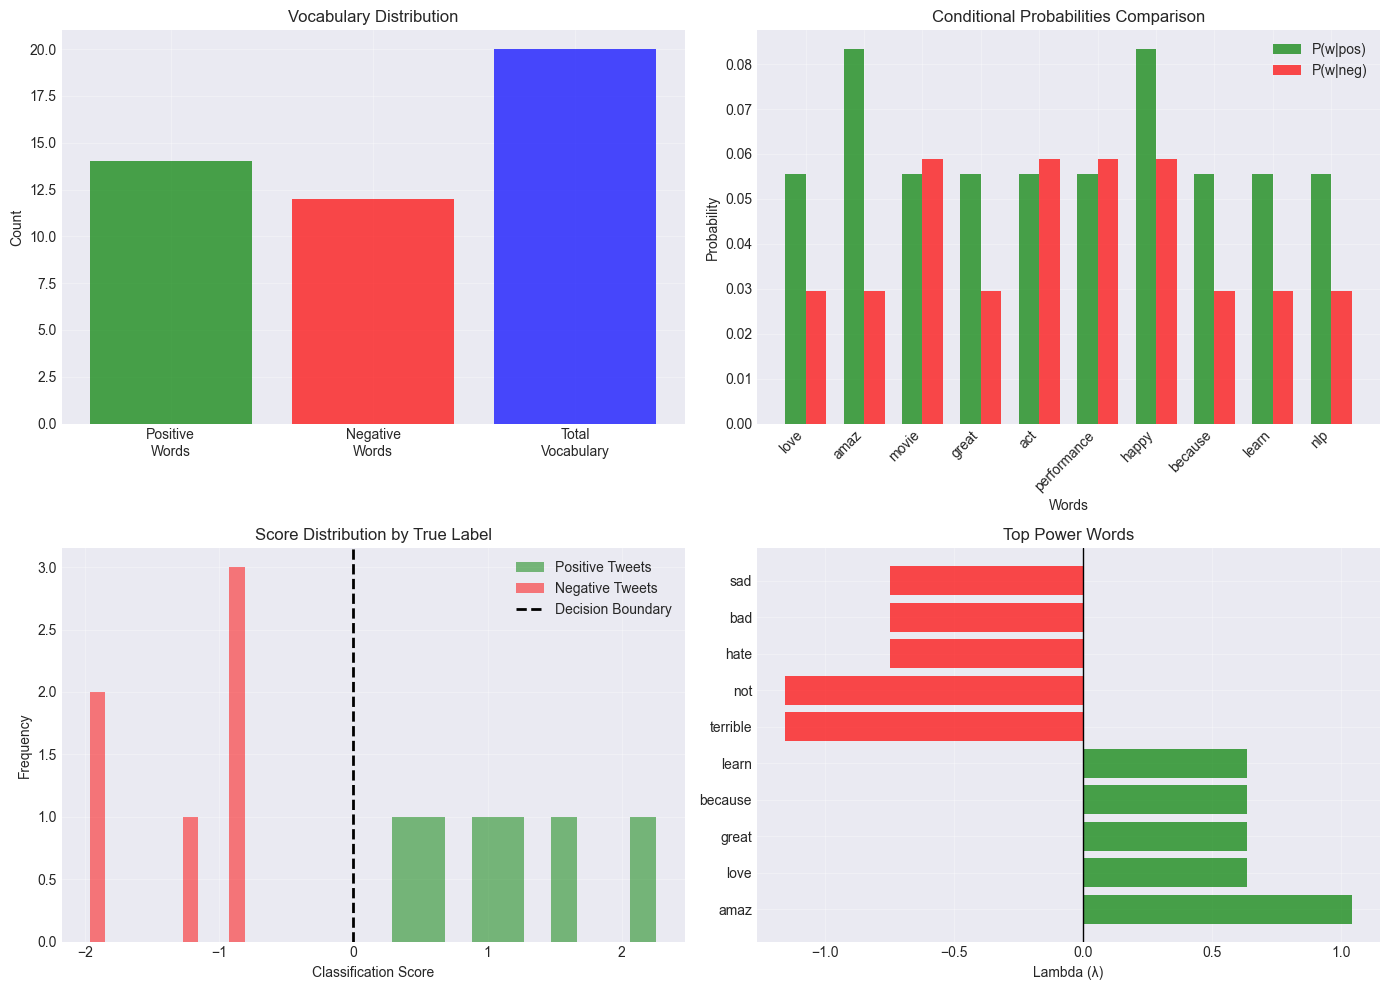

In [14]:
# Create visualization of word influence
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Word Count Distribution
ax1 = axes[0, 0]
pos_words = [w for w in freq_table if freq_table[w]['pos'] > 0]
neg_words = [w for w in freq_table if freq_table[w]['neg'] > 0]
ax1.bar(['Positive\nWords', 'Negative\nWords', 'Total\nVocabulary'],
        [len(pos_words), len(neg_words), V],
        color=['green', 'red', 'blue'], alpha=0.7)
ax1.set_ylabel('Count')
ax1.set_title('Vocabulary Distribution')
ax1.grid(True, alpha=0.3)

# 2. Probability Comparison
ax2 = axes[0, 1]
sample_words = list(lambda_dict.keys())[:10]
pos_probs = [prob_dict[w]['P(w|pos)'] for w in sample_words]
neg_probs = [prob_dict[w]['P(w|neg)'] for w in sample_words]
x = np.arange(len(sample_words))
width = 0.35
ax2.bar(x - width/2, pos_probs, width, label='P(w|pos)', color='green', alpha=0.7)
ax2.bar(x + width/2, neg_probs, width, label='P(w|neg)', color='red', alpha=0.7)
ax2.set_xlabel('Words')
ax2.set_ylabel('Probability')
ax2.set_title('Conditional Probabilities Comparison')
ax2.set_xticks(x)
ax2.set_xticklabels(sample_words, rotation=45, ha='right')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Score Distribution
ax3 = axes[1, 0]
pos_scores = df_results[df_results['label'] == 1]['score']
neg_scores = df_results[df_results['label'] == 0]['score']
ax3.hist(pos_scores, bins=10, alpha=0.5, label='Positive Tweets', color='green')
ax3.hist(neg_scores, bins=10, alpha=0.5, label='Negative Tweets', color='red')
ax3.axvline(x=0, color='black', linestyle='--', linewidth=2, label='Decision Boundary')
ax3.set_xlabel('Classification Score')
ax3.set_ylabel('Frequency')
ax3.set_title('Score Distribution by True Label')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Feature Importance (Top Lambda Scores)
ax4 = axes[1, 1]
top_positive = sorted(lambda_dict.items(), key=lambda x: x[1], reverse=True)[:5]
top_negative = sorted(lambda_dict.items(), key=lambda x: x[1])[:5]
words = [w for w, _ in top_positive] + [w for w, _ in top_negative]
scores = [s for _, s in top_positive] + [s for _, s in top_negative]
colors = ['green']*5 + ['red']*5
ax4.barh(words, scores, color=colors, alpha=0.7)
ax4.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax4.set_xlabel('Lambda (λ)')
ax4.set_title('Top Power Words')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Demonstrate Key Concepts from Notes

### 11.1 Zero Probability Problem (Before Smoothing)

Demonstrating the zero probability problem from Section 4 of your notes. We find a word that appears only in positive tweets (or only in negative tweets) and show:

**Without smoothing:** P(word|neg) = 0/N_neg = 0 ⚠️ BREAKS THE MODEL **With smoothing:** P(word|neg) = 1/(N_neg + V) > 0 ✓ SAFE

This illustrates why Laplacian smoothing is essential - it prevents zero probabilities that would make our classifier fail.


In [15]:
print("="*80)
print("DEMONSTRATING: Zero Probability Problem (Section 4 of Notes)")
print("="*80)

# Calculate without smoothing
def calc_without_smoothing(word):
    pos_count = freq_table.get(word, {'pos': 0})['pos']
    neg_count = freq_table.get(word, {'neg': 0})['neg']

    p_pos = pos_count / N_pos if N_pos > 0 else 0
    p_neg = neg_count / N_neg if N_neg > 0 else 0

    return p_pos, p_neg

# Find a word that appears only in positive tweets
exclusive_words = [w for w in freq_table
                   if freq_table[w]['pos'] > 0 and freq_table[w]['neg'] == 0]

if exclusive_words:
    word = exclusive_words[0]
    p_pos_no_smooth, p_neg_no_smooth = calc_without_smoothing(word)
    p_pos_smooth = prob_dict[word]['P(w|pos)']
    p_neg_smooth = prob_dict[word]['P(w|neg)']

    print(f"\nExample word: '{word}'")
    print(f"Appears in: {freq_table[word]['pos']} positive, {freq_table[word]['neg']} negative tweets")
    print(f"\nWithout Smoothing:")
    print(f"  P({word}|pos) = {p_pos_no_smooth:.4f}")
    print(f"  P({word}|neg) = {p_neg_no_smooth:.4f}  ⚠️  ZERO! Causes problems")
    print(f"\nWith Laplacian Smoothing:")
    print(f"  P({word}|pos) = {p_pos_smooth:.4f}")
    print(f"  P({word}|neg) = {p_neg_smooth:.4f}  ✓  Non-zero, safe to use")

DEMONSTRATING: Zero Probability Problem (Section 4 of Notes)

Example word: 'love'
Appears in: 1 positive, 0 negative tweets

Without Smoothing:
  P(love|pos) = 0.0625
  P(love|neg) = 0.0000  ⚠️  ZERO! Causes problems

With Laplacian Smoothing:
  P(love|pos) = 0.0556
  P(love|neg) = 0.0294  ✓  Non-zero, safe to use



### 11.2 Neutral vs Power Words

Identifying different word categories based on their probability ratios (from Section 3 of your notes):

- **Neutral words** (ratio ≈ 1.0): Appear equally in both classes, don't help classification
- **Positive power words** (ratio > 1.5): Strongly indicate positive sentiment
- **Negative power words** (ratio < 0.67): Strongly indicate negative sentiment

This demonstrates the key insight from your notes: neutral words cancel out, while power words drive the classification decision.

In [16]:
print("\n" + "="*80)
print("DEMONSTRATING: Neutral Words vs Power Words (Section 3 of Notes)")
print("="*80)

# Identify neutral and power words based on ratio
neutral_words = []
power_pos_words = []
power_neg_words = []

for word, probs in prob_dict.items():
    ratio = probs['ratio']
    if 0.9 <= ratio <= 1.1:  # Nearly equal probability
        neutral_words.append((word, ratio))
    elif ratio > 1.5:  # Strongly positive
        power_pos_words.append((word, ratio))
    elif ratio < 0.67:  # Strongly negative
        power_neg_words.append((word, ratio))

print(f"\nNeutral Words (ratio ≈ 1.0):")
for word, ratio in neutral_words[:5]:
    print(f"  {word}: ratio = {ratio:.3f}")

print(f"\nPower Words - Positive (ratio > 1.5):")
for word, ratio in sorted(power_pos_words, key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {word}: ratio = {ratio:.3f}")

print(f"\nPower Words - Negative (ratio < 0.67):")
for word, ratio in sorted(power_neg_words, key=lambda x: x[1])[:5]:
    print(f"  {word}: ratio = {ratio:.3f}")


DEMONSTRATING: Neutral Words vs Power Words (Section 3 of Notes)

Neutral Words (ratio ≈ 1.0):
  movie: ratio = 0.944
  act: ratio = 0.944
  performance: ratio = 0.944
  today: ratio = 0.944
  film: ratio = 0.944

Power Words - Positive (ratio > 1.5):
  amaz: ratio = 2.833
  love: ratio = 1.889
  great: ratio = 1.889
  because: ratio = 1.889
  learn: ratio = 1.889

Power Words - Negative (ratio < 0.67):
  terrible: ratio = 0.315
  not: ratio = 0.315
  hate: ratio = 0.472
  bad: ratio = 0.472
  sad: ratio = 0.472


### 11.3 Impact of Log Transformation

Comparing two equivalent approaches from Section 5 of your notes:

**Method 1 (Multiplicative):** Multiply probability ratios

- Product = ratio₁ × ratio₂ × ratio₃...
- Decision: product > 1 → Positive

**Method 2 (Additive with logs):** Sum lambda scores

- Sum = λ₁ + λ₂ + λ₃...
- Decision: sum > 0 → Positive

Both give identical results, but logs prevent numerical underflow when multiplying many small probabilities. This is why we use log-likelihood in practice!


In [17]:
print("\n" + "="*80)
print("DEMONSTRATING: Product vs Sum with Logs (Section 5 of Notes)")
print("="*80)

# Example calculation with and without logs
test_tweet = "happy learning amazing"
words = test_tweet.split()

print(f"\nTweet: \"{test_tweet}\"")
print(f"\nMethod 1: Direct Probability Ratio (Multiplicative)")
print("-" * 50)

product_ratio = 1.0
for word in words:
    if word in prob_dict:
        ratio = prob_dict[word]['ratio']
        product_ratio *= ratio
        print(f"  {word}: multiply by {ratio:.4f} → running product = {product_ratio:.6f}")

print(f"\nFinal product: {product_ratio:.6f}")
print(f"Decision: {'POSITIVE' if product_ratio > 1 else 'NEGATIVE'}")

print(f"\nMethod 2: Log-Likelihood (Additive)")
print("-" * 50)

log_sum = 0.0
for word in words:
    if word in lambda_dict:
        lambda_score = lambda_dict[word]
        log_sum += lambda_score
        print(f"  {word}: add {lambda_score:.4f} → running sum = {log_sum:.4f}")

print(f"\nFinal sum: {log_sum:.4f}")
print(f"Decision: {'POSITIVE' if log_sum > 0 else 'NEGATIVE'}")

print(f"\n✓ Both methods give same result, but logs prevent underflow!")


DEMONSTRATING: Product vs Sum with Logs (Section 5 of Notes)

Tweet: "happy learning amazing"

Method 1: Direct Probability Ratio (Multiplicative)
--------------------------------------------------
  happy: multiply by 1.4167 → running product = 1.416667

Final product: 1.416667
Decision: POSITIVE

Method 2: Log-Likelihood (Additive)
--------------------------------------------------
  happy: add 0.3483 → running sum = 0.3483

Final sum: 0.3483
Decision: POSITIVE

✓ Both methods give same result, but logs prevent underflow!


## 12. Summary Statistics

Providing a comprehensive summary of the trained Naive Bayes model:

- Dataset statistics (size, balance)
- Vocabulary metrics (unique words, total counts)
- Model parameters (λ scores, log prior)
- Performance metrics (accuracy, correct predictions)
- Word categorization (neutral, positive, negative power words)

This gives you a complete overview of your model's characteristics and helps you understand its behavior at a glance.

In [18]:
print("\n" + "="*80)
print("NAIVE BAYES MODEL SUMMARY")
print("="*80)

print(f"\nTraining Data:")
print(f"  Total tweets: {len(df)}")
print(f"  Positive tweets: {D_pos} ({D_pos/len(df)*100:.1f}%)")
print(f"  Negative tweets: {D_neg} ({D_neg/len(df)*100:.1f}%)")

print(f"\nVocabulary:")
print(f"  Unique words: {V}")
print(f"  Total positive words: {N_pos}")
print(f"  Total negative words: {N_neg}")

print(f"\nModel Parameters:")
print(f"  Lambda scores computed: {len(lambda_dict)}")
print(f"  Log prior: {log_prior:.4f}")

print(f"\nPerformance:")
print(f"  Training accuracy: {accuracy*100:.2f}%")
print(f"  Correctly classified: {(df['label'] == df['predicted']).sum()}/{len(df)}")

print(f"\nWord Categories:")
print(f"  Neutral words (0.9 < ratio < 1.1): {len(neutral_words)}")
print(f"  Positive power words (ratio > 1.5): {len(power_pos_words)}")
print(f"  Negative power words (ratio < 0.67): {len(power_neg_words)}")


NAIVE BAYES MODEL SUMMARY

Training Data:
  Total tweets: 12
  Positive tweets: 6 (50.0%)
  Negative tweets: 6 (50.0%)

Vocabulary:
  Unique words: 20
  Total positive words: 16
  Total negative words: 14

Model Parameters:
  Lambda scores computed: 20
  Log prior: 0.0000

Performance:
  Training accuracy: 100.00%
  Correctly classified: 12/12

Word Categories:
  Neutral words (0.9 < ratio < 1.1): 5
  Positive power words (ratio > 1.5): 8
  Negative power words (ratio < 0.67): 6


## Key Concepts Demonstrated

This notebook has implemented all the core concepts from your Week 2 notes:

1. ✅ **Probability & Bayes' Rule** - Conditional probabilities and word frequencies
2. ✅ **Naive Bayes** - Independence assumption and classification
3. ✅ **Laplacian Smoothing** - Handling zero probabilities (Section 4)
4. ✅ **Log Likelihood** - Converting products to sums (Section 5-6)
5. ✅ **Training Process** - 6-step training pipeline (Section 7)
6. ✅ **Testing & Inference** - Classifying new tweets (Section 8)
7. ✅ **Power Words** - Identifying sentiment-bearing words
8. ✅ **Model Evaluation** - Accuracy and error analysis

## Next Steps

Try these exercises to deepen your understanding:

1. Add more tweets to the dataset and observe how accuracy changes
2. Experiment with different smoothing parameters (α ≠ 1)
3. Test the model with sarcastic tweets (Section 11 of notes)
4. Implement bigrams instead of unigrams
5. Compare with logistic regression from Week 1

**Remember:** Naive Bayes assumes word independence, which isn't always true in real language, but it still works remarkably well as a baseline!
